# DOE-001
## Pure Pursuit Follower
### パラメータ依存性調査
- 対象銘柄: 9984
- クロス・シグナルのみのエントリ・エグジット
- 利確なし
- 評価指標
    - 収益と約定回数

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
name_doe = "doe-001"
date_trade = "20260928"
name_code = "9984"
csvfile = f"../doe/{name_doe}/{date_trade}_{name_code}.csv"
df = pd.read_csv(csvfile)
df

,TYPE_MA_1,PERIOD_MA_1,GAIN_MA_1,GAIN_PREDICT_MA_1,Profit,Transactions
0,PPF,5,0.05,0.3,-6.0,8.0
1,PPF,10,0.05,0.3,-7.0,8.0
2,PPF,15,0.05,0.3,-22.0,10.0
3,PPF,20,0.05,0.3,-24.0,10.0
4,PPF,25,0.05,0.3,-28.0,10.0
...,...,...,...,...,...,...
595,PPF,40,0.50,0.7,-68.0,74.0
596,PPF,45,0.50,0.7,-11.0,56.0
597,PPF,50,0.50,0.7,-15.0,52.0
598,PPF,55,0.50,0.7,-33.0,56.0


In [3]:
cols_param = ["PERIOD_MA_1", "GAIN_MA_1", "GAIN_PREDICT_MA_1"]
cols_response = ["Profit", "Transactions"]

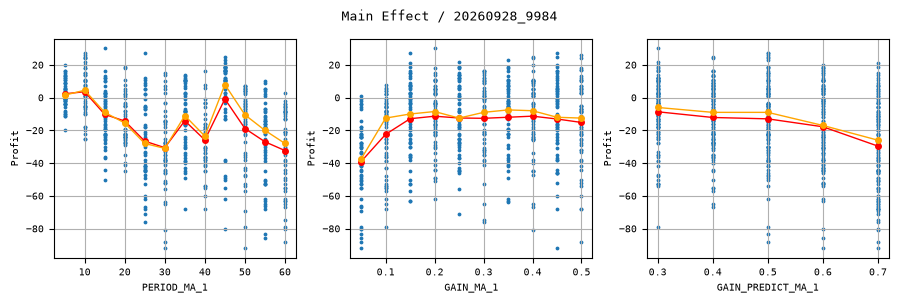

In [4]:
plt.rcParams["font.family"] = "monospace"
plt.rcParams["font.size"] = 7

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

name_y = "Profit"
for ax, col in zip(axes, cols_param):
    ax.scatter(df[col], df[name_y], s=3)

    # x の各水準ごとの平均値
    mean = df.groupby(col)[name_y].mean()
    # 平均値を線で結ぶ
    ax.plot(
        mean.index,
        mean.values,
        "o-",
        color="red",
        markersize=4,
        linewidth=1,
    )
    # x の各水準ごとのメジアン
    median = df.groupby(col)[name_y].median()
    # 平均値を線で結ぶ
    ax.plot(
        median.index,
        median.values,
        "o-",
        color="orange",
        markersize=4,
        linewidth=1,
    )
    
    ax.set(xlabel=col, ylabel=name_y)
    ax.grid(True)

fig.suptitle(f"Main Effect / {date_trade}_{name_code}", fontsize=9)

plt.tight_layout()
pngfile = f"../doe/{name_doe}/{date_trade}_{name_code}_main_effect_{name_y}.png"
plt.savefig(pngfile)
plt.show()

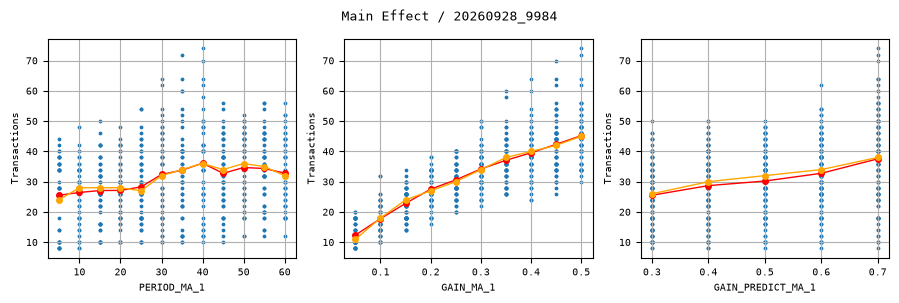

In [5]:
plt.rcParams["font.family"] = "monospace"
plt.rcParams["font.size"] = 7

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

name_y = "Transactions"
for ax, col in zip(axes, cols_param):
    ax.scatter(df[col], df[name_y], s=3)

    # x の各水準ごとの平均値
    mean = df.groupby(col)[name_y].mean()
    # 平均値を線で結ぶ
    ax.plot(
        mean.index,
        mean.values,
        "o-",
        color="red",
        markersize=4,
        linewidth=1,
    )
    # x の各水準ごとのメジアン
    median = df.groupby(col)[name_y].median()
    # 平均値を線で結ぶ
    ax.plot(
        median.index,
        median.values,
        "o-",
        color="orange",
        markersize=4,
        linewidth=1,
    )

    ax.set(xlabel=col, ylabel=name_y)
    ax.grid(True)

fig.suptitle(f"Main Effect / {date_trade}_{name_code}", fontsize=9)

plt.tight_layout()
pngfile = f"../doe/{name_doe}/{date_trade}_{name_code}_main_effect_{name_y}.png"
plt.savefig(pngfile)
plt.show()